# Experimento: Online Shoppers Intention

| Jaime Teixeira - @jaimejrs

Neste notebook vamos construir um experimento de Machine Learning usando o dataset **Online Shoppers Intention**.

A pergunta da aula é simples:

> Podemos usar dados de navegação para prever se uma sessão de e-commerce terminou em compra?

O objetivo é entender o fluxo básico:

1. carregar os dados;
2. conhecer a tabela;
3. identificar a variável-alvo;
4. preparar os dados para o modelo;
5. criar um baseline simples;
6. treinar uma Árvore de Decisão;
7. treinar um Random Forest;
8. comparar os resultados e interpretar os sinais mais importantes.

## 0. Preparação do ambiente

A primeira célula importa as bibliotecas que usaremos.

- `pandas`: leitura e manipulação de tabelas;
- `numpy`: operações numéricas;
- `matplotlib`: gráficos simples;
- `scikit-learn`: modelos e métricas de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Carregando os dados

No Colab, vamos carregar o CSV diretamente de uma URL pública da UCI. Isso evita depender de login ou upload de arquivo durante a aula.

Se preferir usar um arquivo local, baixe o dataset previamente, faça upload no Colab e troque o valor de `URL_DADOS` pelo caminho do arquivo, por exemplo:

```python
URL_DADOS = 'online_shoppers_intention.csv'
```


In [2]:
URL_DADOS = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'

df = pd.read_csv(URL_DADOS)

print(f'Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.')

Dataset carregado com 12330 linhas e 18 colunas.


## 1.1. Dicionário das colunas em português

O dataset vem com nomes de colunas em inglês. Para facilitar a leitura em sala, vamos criar um dicionário com nomes em português e renomear o próprio `df`.

Usaremos nomes sem acento e com `_` para evitar problemas no código. A coluna `Revenue` será traduzida como `Compra`, porque neste dataset ela indica se a sessão terminou ou não em compra.

Depois da próxima célula, todas as análises do notebook usarão os nomes em português.

In [3]:
colunas_pt = {
    'Administrative': 'Paginas_Administrativas',
    'Administrative_Duration': 'Duracao_Paginas_Administrativas',
    'Informational': 'Paginas_Informativas',
    'Informational_Duration': 'Duracao_Paginas_Informativas',
    'ProductRelated': 'Paginas_Produto',
    'ProductRelated_Duration': 'Duracao_Paginas_Produto',
    'BounceRates': 'Taxa_Rejeicao',
    'ExitRates': 'Taxa_Saida',
    'PageValues': 'Valor_Pagina',
    'SpecialDay': 'Dia_Especial',
    'Month': 'Mes',
    'OperatingSystems': 'Sistema_Operacional',
    'Browser': 'Navegador',
    'Region': 'Regiao',
    'TrafficType': 'Tipo_Trafego',
    'VisitorType': 'Tipo_Visitante',
    'Weekend': 'Fim_De_Semana',
    'Revenue': 'Compra'
}

dicionario_colunas = pd.DataFrame(
    colunas_pt.items(),
    columns=['coluna_original', 'coluna_em_portugues']
)

dicionario_colunas

,coluna_original,coluna_em_portugues
0,Administrative,Paginas_Administrativas
1,Administrative_Duration,Duracao_Paginas_Administrativas
2,Informational,Paginas_Informativas
3,Informational_Duration,Duracao_Paginas_Informativas
4,ProductRelated,Paginas_Produto
5,ProductRelated_Duration,Duracao_Paginas_Produto
6,BounceRates,Taxa_Rejeicao
7,ExitRates,Taxa_Saida
8,PageValues,Valor_Pagina
9,SpecialDay,Dia_Especial


In [4]:
df = df.rename(columns=colunas_pt)
df.head()

,Paginas_Administrativas,Duracao_Paginas_Administrativas,Paginas_Informativas,Duracao_Paginas_Informativas,Paginas_Produto,Duracao_Paginas_Produto,Taxa_Rejeicao,Taxa_Saida,Valor_Pagina,Dia_Especial,Mes,Sistema_Operacional,Navegador,Regiao,Tipo_Trafego,Tipo_Visitante,Fim_De_Semana,Compra
0,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.000,0,0.000,2,64.000,0.000,0.100,0.000,0.000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.000,0,0.000,2,2.667,0.050,0.140,0.000,0.000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.000,0,0.000,10,627.500,0.020,0.050,0.000,0.000,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Primeiro contato com a tabela

Antes de pensar em modelo, precisamos saber:

- quantas linhas existem;
- quantas colunas existem;
- quais são os nomes das colunas;
- quais tipos de dados aparecem.

In [5]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

df.columns.tolist()

Linhas: 12330
Colunas: 18


['Paginas_Administrativas',
 'Duracao_Paginas_Administrativas',
 'Paginas_Informativas',
 'Duracao_Paginas_Informativas',
 'Paginas_Produto',
 'Duracao_Paginas_Produto',
 'Taxa_Rejeicao',
 'Taxa_Saida',
 'Valor_Pagina',
 'Dia_Especial',
 'Mes',
 'Sistema_Operacional',
 'Navegador',
 'Regiao',
 'Tipo_Trafego',
 'Tipo_Visitante',
 'Fim_De_Semana',
 'Compra']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Paginas_Administrativas          12330 non-null  int64  
 1   Duracao_Paginas_Administrativas  12330 non-null  float64
 2   Paginas_Informativas             12330 non-null  int64  
 3   Duracao_Paginas_Informativas     12330 non-null  float64
 4   Paginas_Produto                  12330 non-null  int64  
 5   Duracao_Paginas_Produto          12330 non-null  float64
 6   Taxa_Rejeicao                    12330 non-null  float64
 7   Taxa_Saida                       12330 non-null  float64
 8   Valor_Pagina                     12330 non-null  float64
 9   Dia_Especial                     12330 non-null  float64
 10  Mes                              12330 non-null  str    
 11  Sistema_Operacional              12330 non-null  int64  
 12  Navegador                    

## 3. Entendendo a variável-alvo

A variável-alvo é a coluna que queremos prever.

Neste projeto, a variável-alvo é `Compra`:

- `True`: a sessão terminou em compra;
- `False`: a sessão não terminou em compra.

Como a maioria das sessões de e-commerce não vira compra, essa base é desbalanceada. Isso é normal no mundo real.

In [7]:
distribuicao_alvo = (
    df['Compra']
    .value_counts()
    .rename_axis('Compra')
    .reset_index(name='quantidade')
)

distribuicao_alvo['percentual'] = (
    distribuicao_alvo['quantidade'] / len(df) * 100
).round(2)

distribuicao_alvo

,Compra,quantidade,percentual
0,False,10422,84.530
1,True,1908,15.470


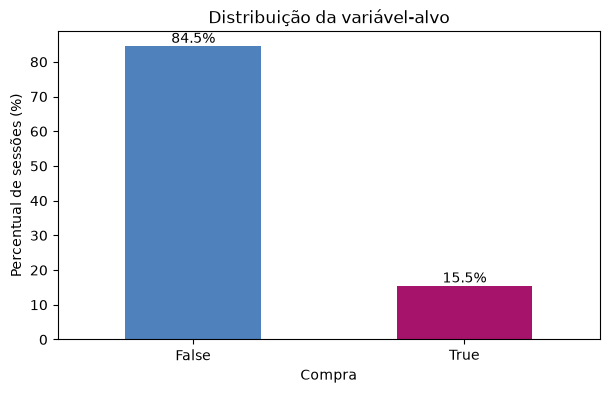

In [8]:
ax = df['Compra'].value_counts(normalize=True).mul(100).plot(
    kind='bar',
    color=['#4f81bd', '#a6136b'],
    figsize=(7, 4)
)

ax.set_title('Distribuição da variável-alvo')
ax.set_xlabel('Compra')
ax.set_ylabel('Percentual de sessões (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=0)
plt.show()

## 4. Tipos de variáveis

Nem toda coluna numérica deve ser tratada como número contínuo.

Por exemplo:

- `Paginas_Produto` é uma contagem: quantidade de páginas de produto visitadas;
- `Duracao_Paginas_Produto` é uma duração: tempo gasto nessas páginas;
- `Sistema_Operacional`, `Navegador`, `Regiao` e `Tipo_Trafego` são códigos: vamos tratá-los como categorias;
- `Fim_De_Semana` é booleano: indica se a sessão aconteceu no fim de semana.

In [9]:
resumo_colunas = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'valores_unicos': df.nunique(),
    'exemplos': [df[col].dropna().unique()[:5].tolist() for col in df.columns]
})

resumo_colunas

,tipo,valores_unicos,exemplos
Paginas_Administrativas,int64,27,"[0, 1, 2, 4, 12]"
Duracao_Paginas_Administrativas,float64,3335,"[0.0, 53.0, 64.6, 6.0, 18.0]"
Paginas_Informativas,int64,17,"[0, 1, 2, 4, 16]"
Duracao_Paginas_Informativas,float64,1258,"[0.0, 120.0, 16.0, 94.0, 93.0]"
Paginas_Produto,int64,311,"[1, 2, 10, 19, 0]"
Duracao_Paginas_Produto,float64,9551,"[0.0, 64.0, 2.666666667, 627.5, 154.2166667]"
Taxa_Rejeicao,float64,1872,"[0.2, 0.0, 0.05, 0.02, 0.015789474]"
Taxa_Saida,float64,4777,"[0.2, 0.1, 0.14, 0.05, 0.024561404]"
Valor_Pagina,float64,2704,"[0.0, 54.17976426, 19.44707913, 38.30849268, 2..."
Dia_Especial,float64,6,"[0.0, 0.4, 0.8, 1.0, 0.2]"


## 5. Estatísticas descritivas

`describe()` resume as variáveis numéricas.

Observe valores mínimos, máximos, médias e quartis. Isso ajuda a identificar escalas diferentes e possíveis assimetrias.

In [10]:
df.describe()

,Paginas_Administrativas,Duracao_Paginas_Administrativas,Paginas_Informativas,Duracao_Paginas_Informativas,Paginas_Produto,Duracao_Paginas_Produto,Taxa_Rejeicao,Taxa_Saida,Valor_Pagina,Dia_Especial,Sistema_Operacional,Navegador,Regiao,Tipo_Trafego
count,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000,12330.000
mean,2.315,80.819,0.504,34.472,31.731,1194.746,0.022,0.043,5.889,0.061,2.124,2.357,3.147,4.070
std,3.322,176.779,1.270,140.749,44.476,1913.669,0.048,0.049,18.568,0.199,0.911,1.717,2.402,4.025
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000
25%,0.000,0.000,0.000,0.000,7.000,184.137,0.000,0.014,0.000,0.000,2.000,2.000,1.000,2.000
50%,1.000,7.500,0.000,0.000,18.000,598.937,0.003,0.025,0.000,0.000,2.000,2.000,3.000,2.000
75%,4.000,93.256,0.000,0.000,38.000,1464.157,0.017,0.050,0.000,0.000,3.000,2.000,4.000,4.000
max,27.000,3398.750,24.000,2549.375,705.000,63973.522,0.200,0.200,361.764,1.000,8.000,13.000,9.000,20.000


### Breve análise do `describe()`

O `describe()` mostra um resumo estatístico das colunas numéricas:

- `count`: quantidade de valores preenchidos. Como aparece igual a **12.330** nas colunas numéricas, isso reforça que não há valores faltantes nelas.
- `mean`: média da coluna.
- `std`: desvio padrão, ou seja, o quanto os valores variam em torno da média.
- `min`, `25%`, `50%`, `75%` e `max`: ajudam a entender a distribuição dos dados.

Alguns sinais importantes:

- Muitas colunas têm mínimo igual a **0**, porque várias sessões não visitam certos tipos de página ou não geram valor em `Valor_Pagina`.
- Em `Valor_Pagina`, a mediana é **0**, mas o máximo passa de **361**. Isso indica uma distribuição bem assimétrica: poucas sessões concentram valores altos.
- `Paginas_Produto` e `Duracao_Paginas_Produto` têm máximos muito maiores que suas medianas, indicando sessões bem mais longas ou intensas que a maioria.
- `Taxa_Rejeicao` e `Taxa_Saida` variam entre **0** e **0,2**, por isso aparecem como números pequenos.

Leitura geral: antes de treinar o modelo, já vemos que as variáveis têm escalas diferentes e algumas distribuições são bastante assimétricas. Isso é comum em dados reais de navegação.

## 6. Comparando compradores e não compradores

Agora vamos comparar algumas variáveis importantes entre sessões que compraram e sessões que não compraram.

Não estamos provando causa. Estamos procurando sinais iniciais.

In [11]:
colunas_interesse = [
    'Valor_Pagina',
    'Taxa_Saida',
    'Taxa_Rejeicao',
    'Paginas_Produto',
    'Duracao_Paginas_Produto'
]

comparacao = df.groupby('Compra')[colunas_interesse].agg(['mean', 'median']).round(3)
comparacao

Valor_Pagina        Taxa_Saida        Taxa_Rejeicao         \
               mean median       mean median          mean median   
Compra                                                              
False         1.976  0.000      0.047  0.029         0.025  0.004   
True         27.265 16.758      0.020  0.016         0.005  0.000   

       Paginas_Produto        Duracao_Paginas_Produto           
                  mean median                    mean   median  
Compra                                                          
False           28.715 16.000                1069.988  510.190  
True            48.210 29.000                1876.210 1109.906

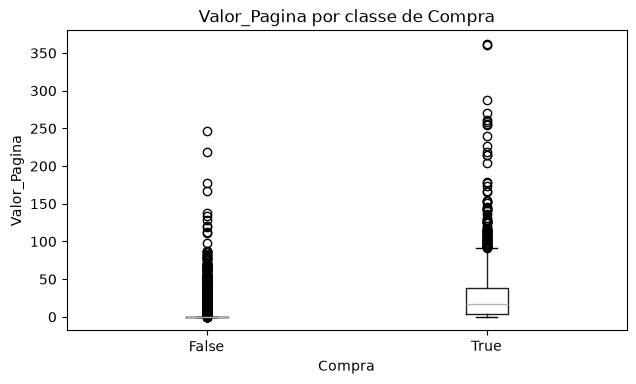

In [12]:
ax = df.boxplot(
    column='Valor_Pagina',
    by='Compra',
    figsize=(7, 4),
    grid=False
)

ax.set_title('Valor_Pagina por classe de Compra')
ax.set_xlabel('Compra')
ax.set_ylabel('Valor_Pagina')
plt.suptitle('')
plt.show()

### Leitura rápida

`Valor_Pagina` costuma ser um dos sinais mais fortes do dataset.

De forma intuitiva, ele representa o valor médio das páginas visitadas antes de uma transação. Sessões com `Valor_Pagina` maior tendem a estar mais próximas de uma compra.

Mesmo assim, cuidado: uma variável ser forte para previsão não significa, sozinha, que ela seja a causa da compra.

### Taxa de compra por mês

Depois de observar `Valor_Pagina`, vamos olhar uma variável de contexto: `Mes`.

A próxima célula calcula, para cada mês, qual percentual de sessões terminou com `Compra = True`.

In [13]:
conversao_por_mes = (
    df.groupby('Mes')['Compra']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .to_frame('taxa_de_compra_%')
)

conversao_por_mes

,taxa_de_compra_%
Mes,
Nov,25.350
Oct,20.950
Sep,19.200
Aug,17.550
Jul,15.280
Dec,12.510
May,10.850
June,10.070
Mar,10.070


### Análise inicial dos dados

Depois desse primeiro contato, já conseguimos tirar algumas conclusões importantes sobre a base:

- O dataset tem **12.330 sessões** e **18 colunas**, sem valores faltantes.
- A variável-alvo `Compra` é desbalanceada: cerca de **84,5%** das sessões não terminaram em compra e apenas **15,5%** terminaram em compra. Por isso, acurácia sozinha pode enganar.
- A maior parte das sessões tem `Valor_Pagina = 0`: aproximadamente **77,9%** dos registros. Mesmo assim, essa variável separa muito bem os grupos: a média de `Valor_Pagina` é cerca de **1,98** para quem não comprou e **27,27** para quem comprou.
- Sessões com compra tendem a navegar mais por produtos: a mediana de `Paginas_Produto` sobe de **16** para **29**, e a mediana de `Duracao_Paginas_Produto` sobe de aproximadamente **510** para **1.110**.
- `Taxa_Rejeicao` e `Taxa_Saida` são menores nas sessões com compra. Isso faz sentido: quem compra tende a abandonar menos rapidamente a navegação.
- O mês também traz contexto. Em `Mes`, novembro aparece com a maior taxa de compra, cerca de **25,35%**, enquanto fevereiro tem taxa bem baixa, cerca de **1,63%**.

## 7. Preparando os dados para classificação

O Scikit-Learn espera receber números.

Por isso vamos:

1. separar `X` e `y`;
2. converter a resposta `Compra` para `0` e `1`;
3. transformar variáveis categóricas em colunas numéricas com `pd.get_dummies()`.

Nesta aula, vamos manter o pré-processamento simples para priorizar entendimento.

In [14]:
X = df.drop(columns='Compra').copy()
y = df['Compra'].astype(int)

colunas_categoricas = [
    'Mes',
    'Sistema_Operacional',
    'Navegador',
    'Regiao',
    'Tipo_Trafego',
    'Tipo_Visitante',
    'Fim_De_Semana'
]

X[colunas_categoricas] = X[colunas_categoricas].astype(str)
X_preparado = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)

print(f'Colunas antes do get_dummies: {X.shape[1]}')
print(f'Colunas depois do get_dummies: {X_preparado.shape[1]}')

X_preparado.head()


Colunas antes do get_dummies: 17
Colunas depois do get_dummies: 68


,Paginas_Administrativas,Duracao_Paginas_Administrativas,Paginas_Informativas,Duracao_Paginas_Informativas,Paginas_Produto,Duracao_Paginas_Produto,Taxa_Rejeicao,Taxa_Saida,Valor_Pagina,Dia_Especial,Mes_Dec,Mes_Feb,Mes_Jul,Mes_June,Mes_Mar,Mes_May,Mes_Nov,Mes_Oct,Mes_Sep,Sistema_Operacional_2,Sistema_Operacional_3,Sistema_Operacional_4,Sistema_Operacional_5,Sistema_Operacional_6,Sistema_Operacional_7,Sistema_Operacional_8,Navegador_10,Navegador_11,Navegador_12,Navegador_13,Navegador_2,Navegador_3,Navegador_4,Navegador_5,Navegador_6,Navegador_7,Navegador_8,Navegador_9,Regiao_2,Regiao_3,Regiao_4,Regiao_5,Regiao_6,Regiao_7,Regiao_8,Regiao_9,Tipo_Trafego_10,Tipo_Trafego_11,Tipo_Trafego_12,Tipo_Trafego_13,Tipo_Trafego_14,Tipo_Trafego_15,Tipo_Trafego_16,Tipo_Trafego_17,Tipo_Trafego_18,Tipo_Trafego_19,Tipo_Trafego_2,Tipo_Trafego_20,Tipo_Trafego_3,Tipo_Trafego_4,Tipo_Trafego_5,Tipo_Trafego_6,Tipo_Trafego_7,Tipo_Trafego_8,Tipo_Trafego_9,Tipo_Visitante_Other,Tipo_Visitante_Returning_Visitor,Fim_De_Semana_True
0,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0.000,0,0.000,2,64.000,0.000,0.100,0.000,0.000,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
2,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
3,0,0.000,0,0.000,2,2.667,0.050,0.140,0.000,0.000,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
4,0,0.000,0,0.000,10,627.500,0.020,0.050,0.000,0.000,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True


## 8. Separando treino e teste

Usamos treino para o modelo aprender.

Usamos teste para avaliar em dados que o modelo ainda não viu.

O parâmetro `stratify=y` mantém a proporção de compras e não compras nas duas partes.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preparado,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Treino: {X_train.shape[0]} linhas')
print(f'Teste: {X_test.shape[0]} linhas')

print('\nDistribuição no treino:')
print(y_train.value_counts(normalize=True).round(3))

print('\nDistribuição no teste:')
print(y_test.value_counts(normalize=True).round(3))

Treino: 9864 linhas
Teste: 2466 linhas

Distribuição no treino:
Compra
0   0.845
1   0.155
Name: proportion, dtype: float64

Distribuição no teste:
Compra
0   0.845
1   0.155
Name: proportion, dtype: float64


## 9. Baseline simples

Antes de treinar um modelo de Machine Learning, precisamos de uma referência mínima.

Aqui o baseline será um `DummyClassifier` com `strategy='most_frequent'`. Ele sempre prevê a classe mais comum no treino. Como a maioria das sessões não termina em compra, esse baseline tende a responder sempre **não comprou**.

Ele não resolve o problema, mas responde uma pergunta importante:

> Nosso modelo consegue fazer melhor do que simplesmente chutar a classe majoritária?

In [16]:
modelo_baseline = DummyClassifier(strategy='most_frequent')
modelo_baseline.fit(X_train, y_train)

y_baseline = modelo_baseline.predict(X_test)

acuracia_baseline = accuracy_score(y_test, y_baseline)
print(f'Acurácia do baseline: {acuracia_baseline:.3f}')

Acurácia do baseline: 0.845


## 10. Treinando uma Árvore de Decisão

A Árvore de Decisão aprende uma sequência de perguntas sobre os dados. Em cada divisão, ela tenta separar melhor os exemplos de compra e não compra.

Neste primeiro modelo vamos limitar a árvore com dois parâmetros simples:

- `max_depth=4`: impede que a árvore fique profunda demais;
- `min_samples_leaf=50`: evita folhas com poucos exemplos.

Essas escolhas deixam o modelo mais fácil de visualizar e reduzem o risco de decorar detalhes específicos do treino.

In [17]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=RANDOM_STATE
)

modelo_arvore.fit(X_train, y_train)

y_pred_arvore = modelo_arvore.predict(X_test)
y_proba_arvore = modelo_arvore.predict_proba(X_test)[:, 1]

print('Árvore de Decisão treinada com sucesso.')

Árvore de Decisão treinada com sucesso.


## 11. Avaliando a Árvore de Decisão

A acurácia mostra a proporção geral de acertos. Ela é útil, mas não basta quando a base é desbalanceada.

Por isso também vamos olhar a matriz de confusão e o relatório de classificação.

In [18]:
acuracia_arvore = accuracy_score(y_test, y_pred_arvore)

print(f'Acurácia do baseline: {acuracia_baseline:.3f}')
print(f'Acurácia da Árvore de Decisão: {acuracia_arvore:.3f}')

Acurácia do baseline: 0.845
Acurácia da Árvore de Decisão: 0.896


In [19]:
matriz_arvore = confusion_matrix(y_test, y_pred_arvore)
matriz_arvore

array([[2032,   52],
       [ 204,  178]])

In [20]:
print(classification_report(
    y_test,
    y_pred_arvore,
    target_names=['não comprou', 'comprou']
))

              precision    recall  f1-score   support

 não comprou       0.91      0.98      0.94      2084
     comprou       0.77      0.47      0.58       382

    accuracy                           0.90      2466
   macro avg       0.84      0.72      0.76      2466
weighted avg       0.89      0.90      0.89      2466



### Como ler a matriz de confusão

A matriz de confusão mostra os acertos e erros por classe:

- canto superior esquerdo: sessões que **não compraram** e foram previstas como não compra;
- canto superior direito: sessões que **não compraram**, mas foram previstas como compra;
- canto inferior esquerdo: sessões que **compraram**, mas foram previstas como não compra;
- canto inferior direito: sessões que **compraram** e foram previstas como compra.

Em problemas de compra, o canto inferior esquerdo merece muita atenção: são oportunidades reais que o modelo deixou passar.

### Análise da Árvore de Decisão

A base é desbalanceada: cerca de **84,5%** das sessões não terminaram em compra e apenas **15,5%** terminaram com `Compra = True`. Por isso, o baseline que sempre prevê **não comprou** já alcança aproximadamente **84,5% de acurácia**.

A Árvore de Decisão chega a aproximadamente **89,6% de acurácia**, melhor que o baseline. Mesmo assim, o ponto mais importante não é apenas a acurácia:

- o modelo acerta muito bem a classe **não comprou**;
- ele encontra parte das compras reais, mas ainda deixa várias compras passarem;
- para a classe **comprou**, precisamos observar principalmente **recall** e **F1-score**.

Em linguagem de negócio: quando o modelo diz que uma sessão tende a comprar, ele costuma estar razoavelmente certo. Porém, ele ainda perde uma parte relevante das compras reais. Se o objetivo fosse acionar uma campanha de remarketing, isso seria uma limitação importante.

## 12. Visualizando a árvore

Antes de avançar para o Random Forest, vale abrir a Árvore de Decisão e observar como ela tomou as primeiras decisões.

Esse é um dos motivos de usarmos árvore em uma aula introdutória: além de prever, ela permite discutir o raciocínio aprendido pelo modelo.

Como limitamos `max_depth`, a visualização fica pequena o suficiente para discutir em sala.

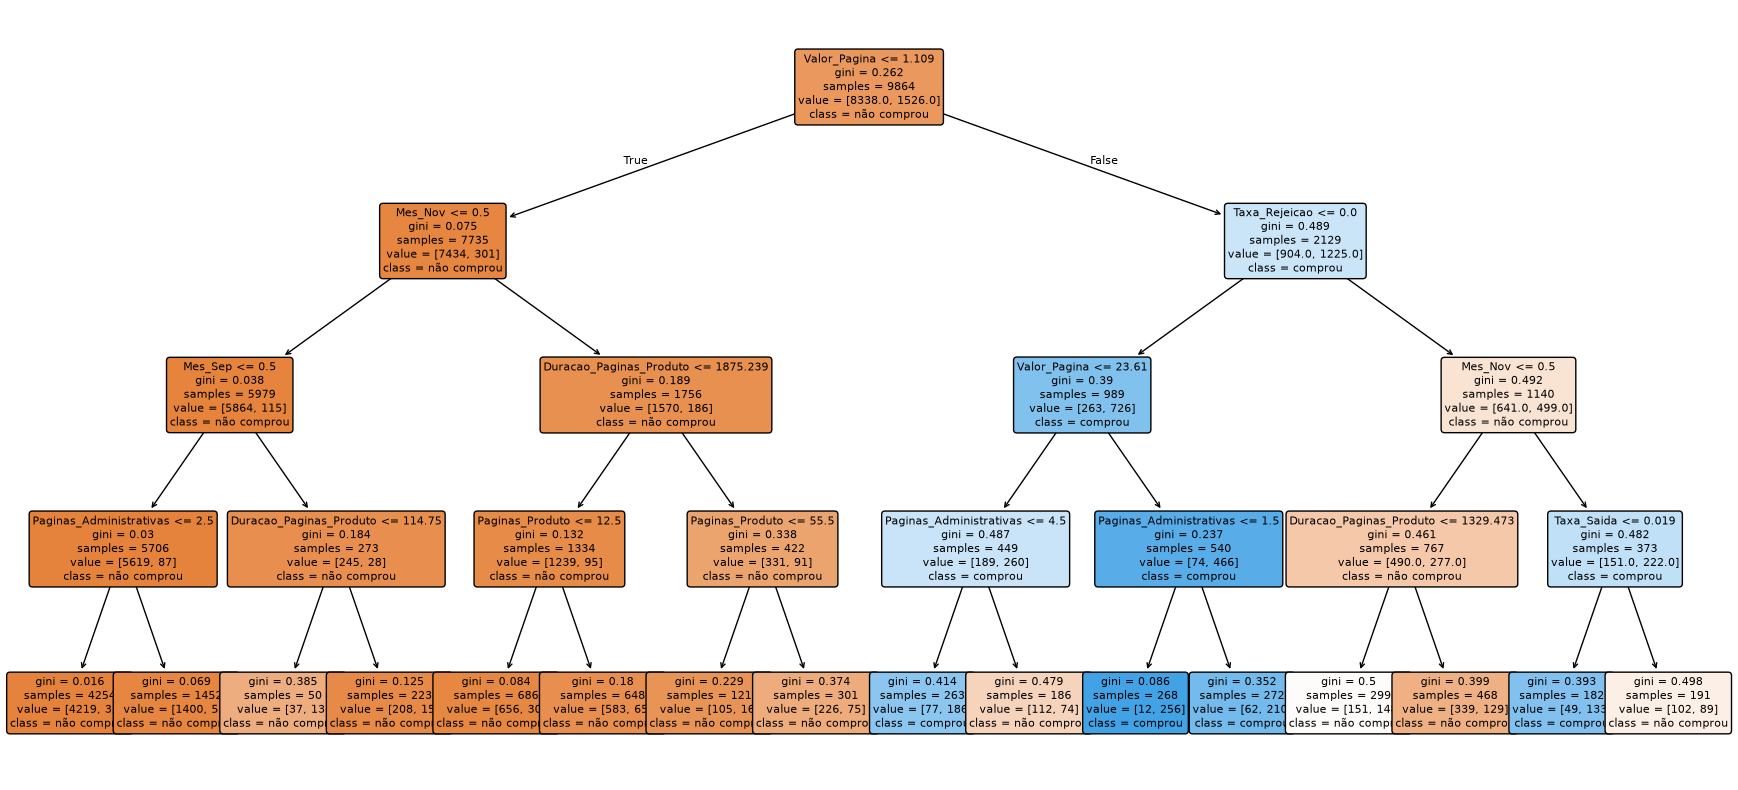

In [21]:
plt.figure(figsize=(22, 10))

plot_tree(
    modelo_arvore,
    feature_names=X_train.columns,
    class_names=['não comprou', 'comprou'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

## 13. Random Forest: várias árvores trabalhando juntas

Depois de entender uma árvore individual, fica mais fácil entender o Random Forest.

Random Forest é um conjunto de várias Árvores de Decisão. Em vez de confiar em uma única árvore, o algoritmo cria muitas árvores com pequenas variações nos dados e nas colunas usadas em cada divisão. No final, as árvores votam na classe mais provável.

Na prática, isso costuma trazer três efeitos importantes:

- o modelo fica menos dependente de uma única sequência de decisões;
- a previsão tende a ser mais estável do que a de uma árvore isolada;
- a interpretação fica menos visual, porque agora temos muitas árvores trabalhando juntas.

Random Forest geralmente lida bem com relações não lineares e não exige normalização das variáveis. Ele também é menos sensível a alguns pontos extremos do que uma árvore única, mas ainda precisa de validação cuidadosa.

In [22]:
modelo_random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

modelo_random_forest.fit(X_train, y_train)

y_pred_rf = modelo_random_forest.predict(X_test)
y_proba_rf = modelo_random_forest.predict_proba(X_test)[:, 1]

print('Random Forest treinado com sucesso.')

Random Forest treinado com sucesso.


## 14. Comparando os modelos da aula

Agora vamos colocar baseline, Árvore de Decisão e Random Forest lado a lado em uma tabela comparativa.

Além da acurácia, vamos olhar métricas focadas na classe **comprou**:

- **precisão**: entre as sessões previstas como compra, quantas realmente compraram;
- **recall**: entre as compras reais, quantas o modelo conseguiu encontrar;
- **F1-score**: equilíbrio entre precisão e recall;
- **ROC AUC**: capacidade geral de separar compras e não compras usando probabilidades.

Essa tabela ajuda a comparar modelos sem depender de uma única métrica.

In [23]:
def calcular_metricas(nome, y_real, y_predito, y_probabilidade=None):
    metricas = {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_real, y_predito),
        'Precisão_compra': precision_score(y_real, y_predito, zero_division=0),
        'Recall_compra': recall_score(y_real, y_predito, zero_division=0),
        'F1_compra': f1_score(y_real, y_predito, zero_division=0),
        'ROC_AUC': np.nan
    }

    if y_probabilidade is not None:
        metricas['ROC_AUC'] = roc_auc_score(y_real, y_probabilidade)

    return metricas

resultados_modelos = pd.DataFrame([
    calcular_metricas('Classe majoritária (baseline)', y_test, y_baseline),
    calcular_metricas('Árvore de Decisão', y_test, y_pred_arvore, y_proba_arvore),
    calcular_metricas('Random Forest', y_test, y_pred_rf, y_proba_rf)
]).set_index('Modelo')

tabela_comparativa_modelos = resultados_modelos.rename(columns={
    'Precisão_compra': 'Precisão (comprou)',
    'Recall_compra': 'Recall (comprou)',
    'F1_compra': 'F1-score (comprou)',
    'ROC_AUC': 'ROC AUC'
}).round(3)

tabela_comparativa_modelos

,Acurácia,Precisão (comprou),Recall (comprou),F1-score (comprou),ROC AUC
Modelo,,,,,
Classe majoritária (baseline),0.845,0.000,0.000,0.000,NaN
Árvore de Decisão,0.896,0.774,0.466,0.582,0.909
Random Forest,0.898,0.759,0.503,0.605,0.914


### Leitura da tabela comparativa

A tabela mostra que o baseline tem acurácia alta porque a base é desbalanceada, mas ele não identifica nenhuma compra. Por isso, o recall e o F1-score da classe **comprou** ficam iguais a zero.

A Árvore de Decisão já aprende padrões úteis e supera o baseline. O Random Forest melhora um pouco o resultado geral e encontra mais compras reais, aumentando o recall da classe **comprou**.

A diferença não é gigantesca, e isso é uma boa discussão para a aula: modelos mais sofisticados nem sempre transformam o resultado de forma dramática. O ganho principal aqui é que o Random Forest tende a ser mais estável, porque combina muitas árvores em vez de depender de uma única estrutura.

In [24]:
matriz_rf = confusion_matrix(y_test, y_pred_rf)
matriz_rf

array([[2023,   61],
       [ 190,  192]])

In [25]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['não comprou', 'comprou']
))

              precision    recall  f1-score   support

 não comprou       0.91      0.97      0.94      2084
     comprou       0.76      0.50      0.60       382

    accuracy                           0.90      2466
   macro avg       0.84      0.74      0.77      2466
weighted avg       0.89      0.90      0.89      2466



### Leitura do Random Forest

O Random Forest encontra mais compras reais do que a árvore configurada para visualização, mas ainda deixa compras passarem.

Isso reforça uma ideia importante: em problemas de negócio, o melhor modelo depende do objetivo. Se quisermos evitar abordar clientes sem intenção de compra, a precisão ganha peso. Se quisermos encontrar o máximo possível de compradores potenciais, o recall passa a ser mais importante.

Por isso a tabela comparativa é mais útil do que olhar apenas uma linha de acurácia.

### Cuidados antes de confiar no modelo

Antes de levar um modelo como esse para produção, precisaríamos responder algumas perguntas:

- A variável `Valor_Pagina` estaria disponível no momento real da previsão?
- O modelo mantém desempenho em dados de meses futuros?
- A empresa prefere errar abordando pessoas que não comprariam ou perder pessoas que comprariam?
- Existe algum custo operacional associado a cada previsão errada?

Essas perguntas mostram que Machine Learning não termina na métrica. A métrica ajuda, mas a decisão precisa considerar o contexto do negócio.

## 15. Quais variáveis mais pesaram nos modelos?

Tanto a Árvore de Decisão quanto o Random Forest conseguem indicar quais variáveis foram mais usadas para separar compra e não compra.

Neste ponto, a turma já viu a árvore por dentro. Agora vamos comparar a importância das variáveis na árvore única e no conjunto de árvores.

In [26]:
importancias_arvore = pd.Series(
    modelo_arvore.feature_importances_,
    index=X_train.columns,
    name='Árvore de Decisão'
)

importancias_rf = pd.Series(
    modelo_random_forest.feature_importances_,
    index=X_train.columns,
    name='Random Forest'
)

importancias_modelos = pd.concat([importancias_arvore, importancias_rf], axis=1)
importancias_modelos.sort_values('Random Forest', ascending=False).head(10)

,Árvore de Decisão,Random Forest
Valor_Pagina,0.814,0.336
Taxa_Saida,0.011,0.088
Duracao_Paginas_Produto,0.028,0.083
Paginas_Produto,0.004,0.072
Duracao_Paginas_Administrativas,0.000,0.056
Taxa_Rejeicao,0.076,0.054
Paginas_Administrativas,0.026,0.044
Duracao_Paginas_Informativas,0.000,0.027
Paginas_Informativas,0.000,0.019
Mes_Nov,0.039,0.019


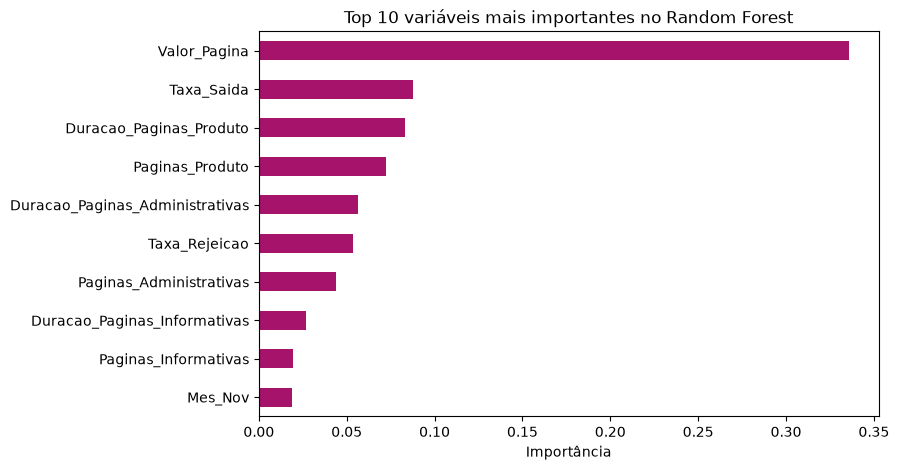

In [27]:
top_10_rf = importancias_rf.sort_values(ascending=False).head(10).sort_values()

ax = top_10_rf.plot(kind='barh', figsize=(8, 5), color='#a6136b')
ax.set_title('Top 10 variáveis mais importantes no Random Forest')
ax.set_xlabel('Importância')
plt.show()

### Leitura das variáveis mais importantes

A variável `Valor_Pagina` aparece como um sinal muito forte nos modelos. Isso conversa com a exploração inicial: sessões com compra têm `Valor_Pagina` muito maior que sessões sem compra.

Outras variáveis, como `Taxa_Rejeicao`, `Taxa_Saida`, `Duracao_Paginas_Produto` e algumas marcações de mês, também aparecem como sinais relevantes.

A leitura correta é: essas variáveis ajudaram o modelo a separar as classes neste conjunto de dados. Isso **não prova causa**. Além disso, em um projeto real, precisaríamos confirmar se `Valor_Pagina` está disponível no momento em que queremos fazer a previsão; caso contrário, ela poderia representar vazamento de informação.

## 16. Experimento extra para testar
Depois de executar o notebook uma vez, podemos testar pequenas mudanças no modelo.

A célula abaixo demonstra uma delas: usar `class_weight='balanced'` na Árvore de Decisão para dar mais atenção à classe minoritária, **comprou**.

Depois dessa demonstração, outras variações possíveis são:

1. Trocar `max_depth=4` por `max_depth=2` ou `max_depth=6`.
2. Remover `Valor_Pagina` das variáveis de classificação e comparar o resultado.
3. Alterar `n_estimators` do Random Forest para observar custo de treino e estabilidade.
4. Observar principalmente o recall da classe **comprou**.

In [28]:
# Experimento extra: árvore tentando dar mais atenção à classe minoritária.
# Execute esta célula depois de entender o modelo principal.

modelo_balanceado = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

modelo_balanceado.fit(X_train, y_train)
y_pred_balanceado = modelo_balanceado.predict(X_test)

print(classification_report(
    y_test,
    y_pred_balanceado,
    target_names=['não comprou', 'comprou']
))

              precision    recall  f1-score   support

 não comprou       0.96      0.85      0.90      2084
     comprou       0.50      0.83      0.62       382

    accuracy                           0.84      2466
   macro avg       0.73      0.84      0.76      2466
weighted avg       0.89      0.84      0.86      2466



## 17. Fechamento

Neste experimento, vimos o ciclo básico de Machine Learning:

- carregamos um dataset real;
- exploramos linhas, colunas e tipos;
- entendemos o alvo `Compra`;
- percebemos o desbalanceamento da classe de compra;
- transformamos categorias em números;
- criamos um baseline com `DummyClassifier`;
- treinamos, avaliamos e visualizamos uma Árvore de Decisão;
- incrementamos o projeto com Random Forest;
- comparamos os modelos em uma tabela com métricas de classificação;
- interpretamos os sinais mais importantes para conversar com o negócio.

O mais importante da aula:

> Machine Learning não começa no modelo. Começa na pergunta, passa pelo entendimento dos dados e termina na interpretação dos resultados.